In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')

In [3]:
import numpy as np
from stable_baselines3.common.env_checker import check_env

# Sequential DDA environment test

In [10]:
from vimms.Common import POSITIVE
from vimms.ChemicalSamplers import MZMLFormulaSampler, MZMLRTandIntensitySampler, MZMLChromatogramSampler

from vimms_gym.env import DDAEnv
from vimms_gym.chemicals import generate_chemicals
from vimms_gym.features import obs_to_dfs

In [5]:
# n_chemicals = (200, 500)
# mz_range = (100, 600)
# rt_range = (0, 300)
# intensity_range = (1E5, 1E10)

In [6]:
n_chemicals = (10000, 20000)
mz_range = (100, 600)
rt_range = (200, 1000)
intensity_range = (1E4, 1E10)

In [7]:
min_mz = mz_range[0]
max_mz = mz_range[1]
min_rt = rt_range[0]
max_rt = rt_range[1]
min_log_intensity = np.log(intensity_range[0])
max_log_intensity = np.log(intensity_range[1])

In [8]:
isolation_window = 0.7
N = 10
rt_tol = 15
mz_tol = 10
min_ms1_intensity = 5000
ionisation_mode = POSITIVE

enable_spike_noise = True
noise_density = 0.1
noise_max_val = 1e3

In [11]:
mzml_filename = 'fullscan_QCB.mzML'
mz_sampler = MZMLFormulaSampler(mzml_filename, min_mz=min_mz, max_mz=max_mz)
ri_sampler = MZMLRTandIntensitySampler(mzml_filename, min_rt=min_rt, max_rt=max_rt,
                                       min_log_intensity=min_log_intensity,
                                       max_log_intensity=max_log_intensity)
cr_sampler = MZMLChromatogramSampler(mzml_filename)

2022-03-31 12:47:22.781 | DEBUG    | mass_spec_utils.data_import.mzml:_load_file:166 - Loaded 2471 scans
2022-03-31 12:47:25.815 | DEBUG    | mass_spec_utils.data_import.mzml:_load_file:166 - Loaded 2471 scans
2022-03-31 12:50:31.738 | DEBUG    | vimms.ChemicalSamplers:_extract_rois:491 - Extracted 516978 good ROIs from fullscan_QCB.mzML


In [12]:
params = {
    'chemical_creator': {
        'mz_range': mz_range,
        'rt_range': rt_range,
        'intensity_range': intensity_range,
        'n_chemicals': n_chemicals,
        'mz_sampler': mz_sampler,
        'ri_sampler': ri_sampler,
        'cr_sampler': cr_sampler,
    },
    'noise': {
        'enable_spike_noise': enable_spike_noise,
        'noise_density': noise_density,
        'noise_max_val': noise_max_val,
        'mz_range': mz_range
    },
    'env': {
        'ionisation_mode': ionisation_mode,
        'rt_range': rt_range,
        'isolation_window': isolation_window,
        'mz_tol': mz_tol,
        'rt_tol': rt_tol,
    }
}

Initialise a new DDA environment that tracks the top most intense peaks.

In [13]:
max_peaks = 100
env = DDAEnv(max_peaks, params)
check_env(env)

Generate an initial observation (MS1 scan)

In [14]:
observation = env.reset()
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

(    intensities  fragmented  excluded  log_intensities
 0      0.274448         0.0       0.0         6.861196
 1      0.274413         0.0       0.0         6.860313
 2      0.274218         0.0       0.0         6.855449
 3      0.273678         0.0       0.0         6.841943
 4      0.273058         0.0       0.0         6.826441
 ..          ...         ...       ...              ...
 95     0.000000         0.0       0.0         0.000000
 96     0.000000         0.0       0.0         0.000000
 97     0.000000         0.0       0.0         0.000000
 98     0.000000         0.0       0.0         0.000000
 99     0.000000         0.0       0.0         0.000000
 
 [100 rows x 4 columns],
                               counts
 ms_level                      1.0000
 fragmented_count              0.0000
 unfragmented_count            1.0000
 excluded_count                0.0000
 unexcluded_count              1.0000
 elapsed_scans_since_start     0.0001
 elapsed_scans_since_last_ms1  0.00

In [15]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
      dtype=float32)

In [16]:
env.features

[mz=335.7196608102146 rt=200 intensity=954.5079072489432 (0.2744478370924232),
 mz=580.1850218117013 rt=200 intensity=953.6659359259445 (0.27441253752553507),
 mz=588.1876077276812 rt=200 intensity=949.0382444452347 (0.27421796390117836),
 mz=306.7213461167686 rt=200 intensity=936.3070449911809 (0.2736777384881954),
 mz=505.82580383245283 rt=200 intensity=921.9038569400884 (0.2730576376592704),
 mz=498.695985872946 rt=200 intensity=918.2081564693073 (0.2728969645953267),
 mz=514.1836330295215 rt=200 intensity=862.0908988870532 (0.2703744286499674),
 mz=549.8849856680683 rt=200 intensity=823.5452445213357 (0.2685447395938626),
 mz=291.77584259746277 rt=200 intensity=775.3051488347551 (0.26613026769159465),
 mz=395.73208342193897 rt=200 intensity=700.6230452843641 (0.26207880015450635),
 mz=327.1785688599878 rt=200 intensity=696.1727478672394 (0.2618239132198534),
 mz=114.64317894063511 rt=200 intensity=664.496237027638 (0.25996116861097673),
 mz=374.78361946715506 rt=200 intensity=621.7

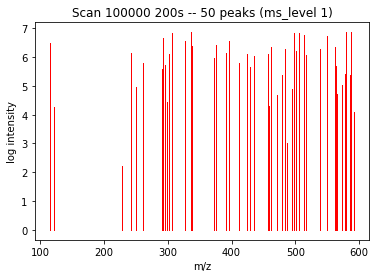

In [17]:
env.render()

Generate 5 ms1 scans

In [27]:
for i in range(5):
    action = max_peaks # ms1
    observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward -0.1
done False


(    intensities  fragmented  excluded  log_intensities
 0      0.275653         0.0       0.0         6.891337
 1      0.274674         0.0       0.0         6.866839
 2      0.273558         0.0       0.0         6.838955
 3      0.273204         0.0       0.0         6.830101
 4      0.272930         0.0       0.0         6.823239
 ..          ...         ...       ...              ...
 95     0.000000         0.0       0.0         0.000000
 96     0.000000         0.0       0.0         0.000000
 97     0.000000         0.0       0.0         0.000000
 98     0.000000         0.0       0.0         0.000000
 99     0.000000         0.0       0.0         0.000000
 
 [100 rows x 4 columns],
                               counts
 ms_level                      1.0000
 fragmented_count              0.0000
 unfragmented_count            1.0000
 excluded_count                0.0000
 unexcluded_count              1.0000
 elapsed_scans_since_start     0.0006
 elapsed_scans_since_last_ms1  0.00

In [28]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
      dtype=float32)

In [29]:
env.features

[mz=463.73088953411525 rt=202.00000000000003 intensity=983.7160894943272 (0.27565349313934756),
 mz=135.054321600862 rt=202.00000000000003 intensity=959.9095885588716 (0.27467356405769167),
 mz=522.9576675889721 rt=202.00000000000003 intensity=933.513324105269 (0.2735582094463276),
 mz=493.81853937933477 rt=202.00000000000003 intensity=925.2843771055498 (0.27320404499891043),
 mz=126.34293374544583 rt=202.00000000000003 intensity=918.9570980092843 (0.27292957751698477),
 mz=532.261877193163 rt=202.00000000000003 intensity=895.2566100470652 (0.2718844156926524),
 mz=161.89556510933562 rt=202.00000000000003 intensity=882.7827027772337 (0.27132316322395633),
 mz=327.86325552200856 rt=202.00000000000003 intensity=787.950942617566 (0.2667774332943383),
 mz=455.5422837545649 rt=202.00000000000003 intensity=740.0879253830161 (0.2642707598890025),
 mz=400.3605321032435 rt=202.00000000000003 intensity=729.1042611797162 (0.2636726696493306),
 mz=158.13676510881703 rt=202.00000000000003 intensity

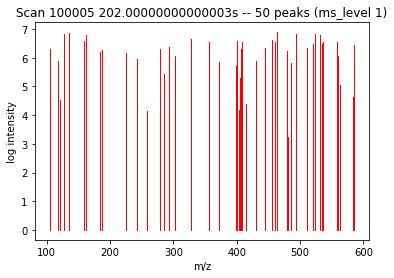

In [30]:
env.render()

Target the most intense precursor for fragmentation, and generate an MS2 scan from that

In [31]:
action = 0
observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward 0
done False


(    intensities  fragmented  excluded  log_intensities
 0      0.275653         0.2  0.026667         6.891337
 1      0.274674         0.0  0.000000         6.866839
 2      0.273558         0.0  0.000000         6.838955
 3      0.273204         0.0  0.000000         6.830101
 4      0.272930         0.0  0.000000         6.823239
 ..          ...         ...       ...              ...
 95     0.000000         0.0  0.000000         0.000000
 96     0.000000         0.0  0.000000         0.000000
 97     0.000000         0.0  0.000000         0.000000
 98     0.000000         0.0  0.000000         0.000000
 99     0.000000         0.0  0.000000         0.000000
 
 [100 rows x 4 columns],
                               counts
 ms_level                      2.0000
 fragmented_count              0.0100
 unfragmented_count            0.9900
 excluded_count                0.0100
 unexcluded_count              0.9900
 elapsed_scans_since_start     0.0007
 elapsed_scans_since_last_ms1  0.01

In [32]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
      dtype=float32)

In [33]:
env.features

[mz=463.73088953411525 rt=202.00000000000003 intensity=983.7160894943272 (0.27565349313934756),
 mz=135.054321600862 rt=202.00000000000003 intensity=959.9095885588716 (0.27467356405769167),
 mz=522.9576675889721 rt=202.00000000000003 intensity=933.513324105269 (0.2735582094463276),
 mz=493.81853937933477 rt=202.00000000000003 intensity=925.2843771055498 (0.27320404499891043),
 mz=126.34293374544583 rt=202.00000000000003 intensity=918.9570980092843 (0.27292957751698477),
 mz=532.261877193163 rt=202.00000000000003 intensity=895.2566100470652 (0.2718844156926524),
 mz=161.89556510933562 rt=202.00000000000003 intensity=882.7827027772337 (0.27132316322395633),
 mz=327.86325552200856 rt=202.00000000000003 intensity=787.950942617566 (0.2667774332943383),
 mz=455.5422837545649 rt=202.00000000000003 intensity=740.0879253830161 (0.2642707598890025),
 mz=400.3605321032435 rt=202.00000000000003 intensity=729.1042611797162 (0.2636726696493306),
 mz=158.13676510881703 rt=202.00000000000003 intensity

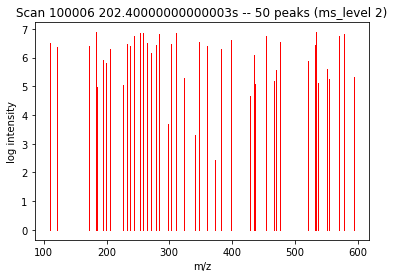

In [34]:
env.render()

Target the next most intense precursor for fragmentation, and generate an MS2 scan

In [35]:
action = 1
observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward 0
done False


(    intensities  fragmented  excluded  log_intensities
 0      0.275653         0.2      0.04         6.891337
 1      0.274674         0.2      0.04         6.866839
 2      0.273558         0.0      0.00         6.838955
 3      0.273204         0.0      0.00         6.830101
 4      0.272930         0.0      0.00         6.823239
 ..          ...         ...       ...              ...
 95     0.000000         0.0      0.00         0.000000
 96     0.000000         0.0      0.00         0.000000
 97     0.000000         0.0      0.00         0.000000
 98     0.000000         0.0      0.00         0.000000
 99     0.000000         0.0      0.00         0.000000
 
 [100 rows x 4 columns],
                               counts
 ms_level                      2.0000
 fragmented_count              0.0200
 unfragmented_count            0.9800
 excluded_count                0.0200
 unexcluded_count              0.9800
 elapsed_scans_since_start     0.0008
 elapsed_scans_since_last_ms1  0.02

In [36]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
      dtype=float32)

In [37]:
env.features

[mz=463.73088953411525 rt=202.00000000000003 intensity=983.7160894943272 (0.27565349313934756),
 mz=135.054321600862 rt=202.00000000000003 intensity=959.9095885588716 (0.27467356405769167),
 mz=522.9576675889721 rt=202.00000000000003 intensity=933.513324105269 (0.2735582094463276),
 mz=493.81853937933477 rt=202.00000000000003 intensity=925.2843771055498 (0.27320404499891043),
 mz=126.34293374544583 rt=202.00000000000003 intensity=918.9570980092843 (0.27292957751698477),
 mz=532.261877193163 rt=202.00000000000003 intensity=895.2566100470652 (0.2718844156926524),
 mz=161.89556510933562 rt=202.00000000000003 intensity=882.7827027772337 (0.27132316322395633),
 mz=327.86325552200856 rt=202.00000000000003 intensity=787.950942617566 (0.2667774332943383),
 mz=455.5422837545649 rt=202.00000000000003 intensity=740.0879253830161 (0.2642707598890025),
 mz=400.3605321032435 rt=202.00000000000003 intensity=729.1042611797162 (0.2636726696493306),
 mz=158.13676510881703 rt=202.00000000000003 intensity

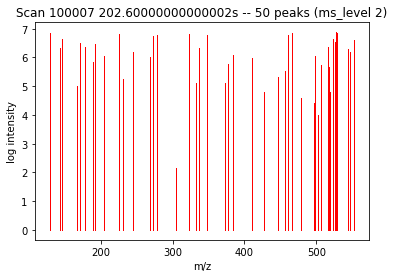

In [38]:
env.render()

Repeat targeting of the same precursor produces a small or no reward

In [39]:
for i in range(10):
    action = 0
    observation, reward, done, info = env.step(action)
    print('reward', reward)
    # print('done', done)
    # pp.pprint(observation)
    # env.render()

reward 0
reward 0
reward 0
reward 0
reward 0
reward 0
reward 0
reward 0
reward 0
reward 0


In [40]:
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

(    intensities  fragmented  excluded  log_intensities
 0      0.275653         1.0  0.173333         6.891337
 1      0.274674         0.2  0.173333         6.866839
 2      0.273558         0.0  0.000000         6.838955
 3      0.273204         0.0  0.000000         6.830101
 4      0.272930         0.0  0.000000         6.823239
 ..          ...         ...       ...              ...
 95     0.000000         0.0  0.000000         0.000000
 96     0.000000         0.0  0.000000         0.000000
 97     0.000000         0.0  0.000000         0.000000
 98     0.000000         0.0  0.000000         0.000000
 99     0.000000         0.0  0.000000         0.000000
 
 [100 rows x 4 columns],
                               counts
 ms_level                      2.0000
 fragmented_count              0.0200
 unfragmented_count            0.9800
 excluded_count                0.0200
 unexcluded_count              0.9800
 elapsed_scans_since_start     0.0018
 elapsed_scans_since_last_ms1  0.12

In [41]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
      dtype=float32)

In [42]:
env.features

[mz=463.73088953411525 rt=202.00000000000003 intensity=983.7160894943272 (0.27565349313934756),
 mz=135.054321600862 rt=202.00000000000003 intensity=959.9095885588716 (0.27467356405769167),
 mz=522.9576675889721 rt=202.00000000000003 intensity=933.513324105269 (0.2735582094463276),
 mz=493.81853937933477 rt=202.00000000000003 intensity=925.2843771055498 (0.27320404499891043),
 mz=126.34293374544583 rt=202.00000000000003 intensity=918.9570980092843 (0.27292957751698477),
 mz=532.261877193163 rt=202.00000000000003 intensity=895.2566100470652 (0.2718844156926524),
 mz=161.89556510933562 rt=202.00000000000003 intensity=882.7827027772337 (0.27132316322395633),
 mz=327.86325552200856 rt=202.00000000000003 intensity=787.950942617566 (0.2667774332943383),
 mz=455.5422837545649 rt=202.00000000000003 intensity=740.0879253830161 (0.2642707598890025),
 mz=400.3605321032435 rt=202.00000000000003 intensity=729.1042611797162 (0.2636726696493306),
 mz=158.13676510881703 rt=202.00000000000003 intensity

Making an invalid move produces negative reward.

In [44]:
action = 50 # no precursor to fragment at this index
observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward -1.0
done False


(    intensities  fragmented  excluded  log_intensities
 0      0.275653         1.0       0.2         6.891337
 1      0.274674         0.2       0.2         6.866839
 2      0.273558         0.0       0.0         6.838955
 3      0.273204         0.0       0.0         6.830101
 4      0.272930         0.0       0.0         6.823239
 ..          ...         ...       ...              ...
 95     0.000000         0.0       0.0         0.000000
 96     0.000000         0.0       0.0         0.000000
 97     0.000000         0.0       0.0         0.000000
 98     0.000000         0.0       0.0         0.000000
 99     0.000000         0.0       0.0         0.000000
 
 [100 rows x 4 columns],
                               counts
 ms_level                       2.000
 fragmented_count               0.040
 unfragmented_count             0.960
 excluded_count                 0.030
 unexcluded_count               0.970
 elapsed_scans_since_start      0.002
 elapsed_scans_since_last_ms1   0.1

In [45]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
      dtype=float32)

In [46]:
env.features

[mz=463.73088953411525 rt=202.00000000000003 intensity=983.7160894943272 (0.27565349313934756),
 mz=135.054321600862 rt=202.00000000000003 intensity=959.9095885588716 (0.27467356405769167),
 mz=522.9576675889721 rt=202.00000000000003 intensity=933.513324105269 (0.2735582094463276),
 mz=493.81853937933477 rt=202.00000000000003 intensity=925.2843771055498 (0.27320404499891043),
 mz=126.34293374544583 rt=202.00000000000003 intensity=918.9570980092843 (0.27292957751698477),
 mz=532.261877193163 rt=202.00000000000003 intensity=895.2566100470652 (0.2718844156926524),
 mz=161.89556510933562 rt=202.00000000000003 intensity=882.7827027772337 (0.27132316322395633),
 mz=327.86325552200856 rt=202.00000000000003 intensity=787.950942617566 (0.2667774332943383),
 mz=455.5422837545649 rt=202.00000000000003 intensity=740.0879253830161 (0.2642707598890025),
 mz=400.3605321032435 rt=202.00000000000003 intensity=729.1042611797162 (0.2636726696493306),
 mz=158.13676510881703 rt=202.00000000000003 intensity

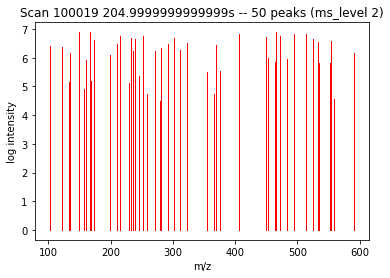

In [47]:
env.render()

Generate lots of MS1 scans

In [48]:
for i in range(100):
    action = max_peaks # ms1
    observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward -0.1
done False


(    intensities  fragmented  excluded  log_intensities
 0      0.869079         0.0       0.0        21.726967
 1      0.747210         0.0       0.0        18.680250
 2      0.617879         0.0       0.0        15.446972
 3      0.615055         0.0       0.0        15.376377
 4      0.613884         0.0       0.0        15.347107
 ..          ...         ...       ...              ...
 95     0.000000         0.0       0.0         0.000000
 96     0.000000         0.0       0.0         0.000000
 97     0.000000         0.0       0.0         0.000000
 98     0.000000         0.0       0.0         0.000000
 99     0.000000         0.0       0.0         0.000000
 
 [100 rows x 4 columns],
                               counts
 ms_level                       1.000
 fragmented_count               0.000
 unfragmented_count             1.000
 excluded_count                 0.000
 unexcluded_count               1.000
 elapsed_scans_since_start      0.012
 elapsed_scans_since_last_ms1   0.0

In [49]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
      dtype=float32)

In [50]:
env.features

[mz=116.57889783184598 rt=244.80000000000044 intensity=2728362015.2299085 (0.8690786908661328),
 mz=238.69506782596287 rt=244.80000000000044 intensity=129637168.96397313 (0.7472100039330164),
 mz=260.50248531952366 rt=244.80000000000044 intensity=5111341.194362746 (0.6178788956956924),
 mz=230.33769832325655 rt=244.80000000000044 intensity=4762948.004411903 (0.6150550945264288),
 mz=126.43651329443006 rt=244.80000000000044 intensity=4625557.614901933 (0.6138842994818178),
 mz=258.31555820708115 rt=244.80000000000044 intensity=868213.2179121305 (0.5469677042493263),
 mz=260.9245189810036 rt=244.80000000000044 intensity=488236.97156209074 (0.5239422465773717),
 mz=260.0423342894808 rt=244.80000000000044 intensity=476444.5081565458 (0.5229642615248256),
 mz=118.68376311999482 rt=244.80000000000044 intensity=233621.3941007821 (0.4944582844031264),
 mz=118.59833646007303 rt=244.80000000000044 intensity=203977.68493479834 (0.48903063517074313),
 mz=247.32535661186122 rt=244.80000000000044 in

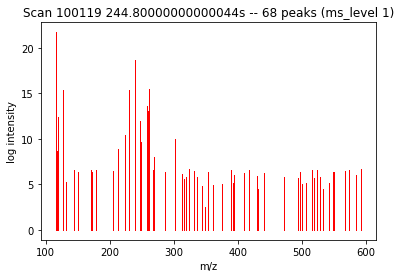

In [51]:
env.render()